In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math

## **1. PROBLEMA DE LOS N-CABALLOS**

Coloca el máximo número de caballos sin que se ataquen.

Lógica Combinatoria: Un caballo siempre ataca a una casilla de color opuesto.

Solución: Colocar caballos en TODAS las casillas del mismo color (ej. negras).

In [ ]:
def resolver_n_caballos(n):
    tablero = np.zeros((n, n))
    contador = 0

    # Llenamos estilo ajedrez (solo en casillas donde (i+j) es par)
    for i in range(n):
        for j in range(n):
            if (i + j) % 2 == 0:
                tablero[i][j] = 1 # 1 representa un caballo
                contador += 1

    return tablero, contador

In [ ]:
def graficar_tablero(tablero, titulo):
    n = len(tablero)
    plt.figure(figsize=(5, 5))
    plt.imshow(tablero, cmap='binary', extent=[0, n, 0, n])

    # Dibujar las piezas
    for i in range(n):
        for j in range(n):
            if tablero[i][j] == 1:
                # Coordenadas para matplotlib (invertidas en Y)
                plt.text(j + 0.5, n - i - 0.5, '♞', fontsize=20,
                         ha='center', va='center', color='red' if tablero[i][j]==1 else 'blue')

    plt.grid(True, which='both', color='gray', linestyle='-', linewidth=0.5)
    plt.xticks(np.arange(0, n+1, 1))
    plt.yticks(np.arange(0, n+1, 1))
    plt.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    plt.title(titulo)
    plt.show()

--- RESULTADO N-CABALLOS (Tablero 8x8) ---
Máximo número de caballos sin atacarse: 32
Estrategia: Ocupar todas las casillas del mismo color.


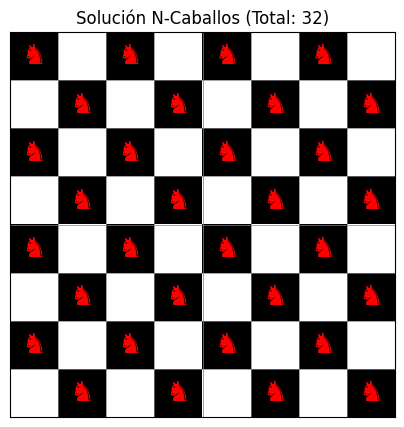

In [ ]:
N_CABALLOS = 8
tablero_caballos, total_caballos = resolver_n_caballos(N_CABALLOS)
print(f"--- RESULTADO N-CABALLOS (Tablero {N_CABALLOS}x{N_CABALLOS}) ---")
print(f"Máximo número de caballos sin atacarse: {total_caballos}")
print("Estrategia: Ocupar todas las casillas del mismo color.")
graficar_tablero(tablero_caballos, f"Solución N-Caballos (Total: {total_caballos})")

## **2. N-REINAS CON SIMULATED ANNEALING**

In [ ]:
def costo_ataques(estado):
    """Calcula cuántos pares de reinas se atacan (solo diagonales,
    ya que por diseño no comparten fila ni columna)."""
    n = len(estado)
    ataques = 0
    for i in range(n):
        for j in range(i + 1, n):
            # Si la distancia en filas es igual a la distancia en columnas, es diagonal
            if abs(estado[i] - estado[j]) == abs(i - j):
                ataques += 1
    return ataques

In [ ]:
def simulated_annealing_n_reinas(n, temp_inicial=1000, enfriamiento=0.95):
    # 1. Estado inicial aleatorio
    estado_actual = list(range(n))
    random.shuffle(estado_actual)
    costo_actual = costo_ataques(estado_actual)

    temp = temp_inicial
    iteraciones = 0

    while temp > 0.1 and costo_actual > 0:
        # 2. Generar vecino (intercambiar dos filas aleatorias)
        nuevo_estado = estado_actual[:]
        i, j = random.sample(range(n), 2)
        nuevo_estado[i], nuevo_estado[j] = nuevo_estado[j], nuevo_estado[i]

        costo_nuevo = costo_ataques(nuevo_estado)
        delta_energia = costo_nuevo - costo_actual

        # 3. Decisión de aceptación
        # Si mejora (delta < 0), aceptamos siempre.
        # Si empeora, aceptamos con probabilidad e^(-delta/T)
        if delta_energia < 0 or random.random() < math.exp(-delta_energia / temp):
            estado_actual = nuevo_estado
            costo_actual = costo_nuevo

        # 4. Enfriamiento
        temp *= enfriamiento
        iteraciones += 1

    return estado_actual, costo_actual, iteraciones

Ejecucion Reinas


--- RESULTADO N-REINAS (Simulated Annealing) ---
Tablero: 8x8
Ataques finales (Energía): 0
Iteraciones realizadas: 145
Configuración (Filas por columna): [2, 7, 3, 6, 0, 5, 1, 4]


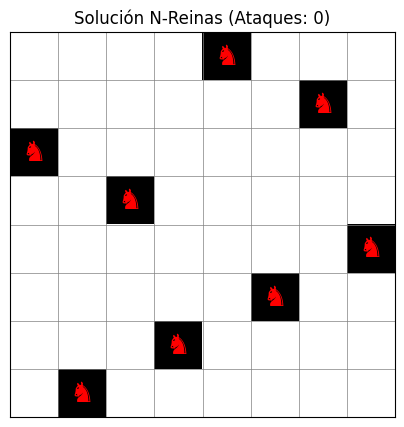

In [ ]:
N_REINAS = 8 # Puedes probar con 16, 32, etc.
solucion, ataques, iters = simulated_annealing_n_reinas(N_REINAS)

# Convertir solución a matriz para graficar
matriz_reinas = np.zeros((N_REINAS, N_REINAS))
for col, fila in enumerate(solucion):
    matriz_reinas[fila][col] = 1

print(f"\n--- RESULTADO N-REINAS (Simulated Annealing) ---")
print(f"Tablero: {N_REINAS}x{N_REINAS}")
print(f"Ataques finales (Energía): {ataques}")
print(f"Iteraciones realizadas: {iters}")
print(f"Configuración (Filas por columna): {solucion}")

graficar_tablero(matriz_reinas, f"Solución N-Reinas (Ataques: {ataques})")